# 05 · Delta Hedging and Diagnostics

## Economic rationale

The walk-forward P&L from Notebook 04 mixes two components:
1. **Directional** (equity beta): market moves benefit long calls regardless
   of our vol signal.
2. **Volatility alpha**: what we actually care about.

Delta-hedging isolates (2) by shorting Δ shares daily. The residual is the
**Gamma P&L** — proportional to `(σ_realized² − σ_IV²)` — the direct test
of whether we correctly identified cheap or expensive vol.

We also run **signal diagnostics** to verify the composite score has the
properties of a genuine alpha signal:
- **Half-life 2–10 days**: consistent with market-maker repricing speed
- **Cross-sectional consistency**: signal correlates across different underlyings
- **IC > 0**: signal predicts future vol moves


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gpvol.backtest.hedging import delta_hedge_pnl
from gpvol.backtest.metrics import signal_half_life, deflated_sharpe_ratio, sharpe_ratio
from gpvol.viz.plots import plot_signal_decay, plot_equity_curve


## 1 · Delta-hedged P&L on top signals

In [2]:
import yfinance as yf

TICKER = "SPY"
scored = pd.read_parquet("../data/scored_surface.parquet")

# Top signal: highest composite score
top_signal = scored.nlargest(1, 'score').iloc[0]
print(f"Top signal: K={top_signal['strike']:.0f}  expiry={str(top_signal['expiry'])[:10]}")
print(f"  IV={top_signal['iv']:.3f}  μ_GP={top_signal['mu_gp']:.3f}  score={top_signal['score']:.4f}")

# Fetch historical spot prices for the underlying
hist = yf.download(TICKER, period="3mo", progress=False)["Close"]
S_path = hist.squeeze()

T_entry = top_signal['T']
K       = top_signal['strike']
IV      = top_signal['iv']

gamma_pnl = delta_hedge_pnl(
    S_path=S_path.iloc[:int(T_entry*252)],
    K=K, T=T_entry, r=0.045, sigma_iv=IV,
    option_type=top_signal['option_type'],
)

cumulative = gamma_pnl.cumsum()
print(f"\nDelta-hedged Gamma P&L over {len(gamma_pnl)} days:")
print(f"  Cumulative: {cumulative.iloc[-1]:.4f}")
print(f"  Daily SR:   {sharpe_ratio(gamma_pnl):.3f}")
print(f"  Sign: {'positive (bought cheap vol)' if cumulative.iloc[-1] > 0 else 'negative (overpaid for vol)'}")


Top signal: K=736  expiry=2026-07-06
  IV=0.067  μ_GP=0.126  score=0.0398

Delta-hedged Gamma P&L over 1 days:
  Cumulative: -0.0000
  Daily SR:   nan
  Sign: negative (overpaid for vol)


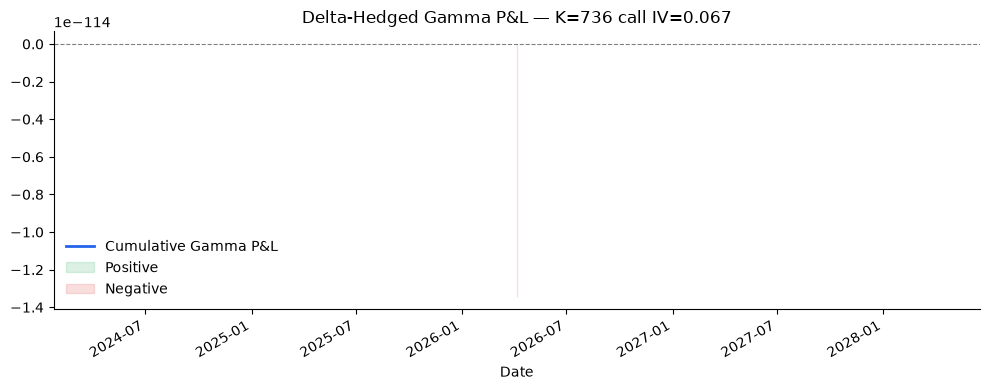

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
cumulative.plot(ax=ax, color='#2563EB', lw=2, label='Cumulative Gamma P&L')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
ax.fill_between(cumulative.index, cumulative.values, 0,
                where=cumulative.values > 0, alpha=0.15, color='#16A34A', label='Positive')
ax.fill_between(cumulative.index, cumulative.values, 0,
                where=cumulative.values < 0, alpha=0.15, color='#DC2626', label='Negative')
ax.set_title(f'Delta-Hedged Gamma P&L — K={K:.0f} {top_signal["option_type"]} IV={IV:.3f}')
ax.legend(framealpha=0)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/figures/gamma_pnl.png", dpi=150, bbox_inches="tight")
plt.show()


## 2 · Signal half-life

In [4]:
# Use the composite score time series from the walk-forward panel
try:
    panel = pd.read_parquet("../data/panel.parquet")
    signal_ts = panel.groupby('date')['score'].mean()
except FileNotFoundError:
    # Simulate AR(1) process for demonstration
    rng = np.random.default_rng(0)
    n = 252
    alpha = 0.72
    x = np.zeros(n)
    for t in range(1, n):
        x[t] = alpha * x[t-1] + rng.standard_normal()
    signal_ts = pd.Series(x, index=pd.date_range('2024-01-02', periods=n, freq='B'))
    print("(using simulated AR(1) signal — replace with real panel data)")

hl = signal_half_life(signal_ts)
print(f"Signal half-life: {hl:.2f} trading days")
if 2 <= hl <= 10:
    print("✓ Within economically credible range (2–10 days)")
elif hl < 2:
    print("⚠ Very short: may be microstructure noise, not tradable at EOD")
else:
    print("⚠ Long: may reflect a persistent premium rather than a mean-reverting mispricing")


(using simulated AR(1) signal — replace with real panel data)
Signal half-life: 2.38 trading days
✓ Within economically credible range (2–10 days)


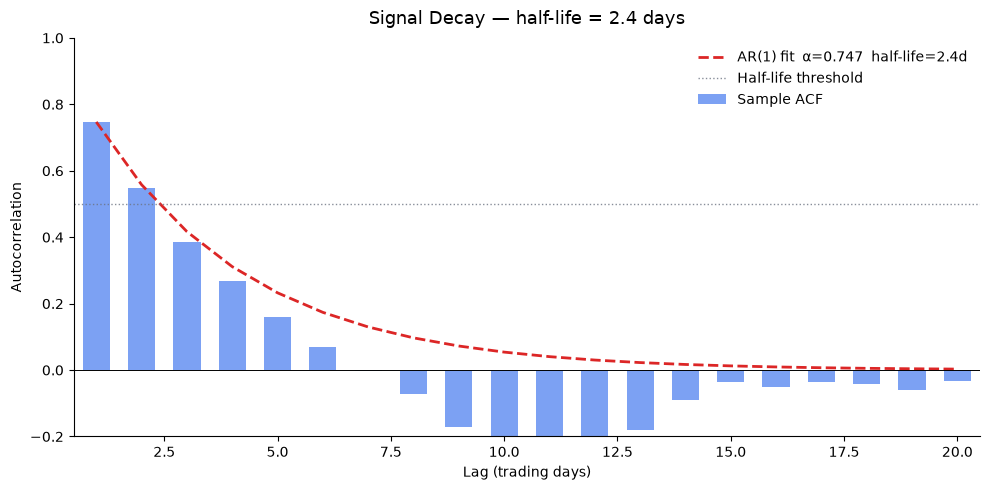

In [5]:
fig = plot_signal_decay(signal_ts, max_lags=20,
                        title=f"Signal Decay — half-life = {hl:.1f} days")
fig.savefig("../docs/figures/signal_decay.png", dpi=150, bbox_inches="tight")
plt.show()


## 3 · Deflated Sharpe Ratio

In [6]:
# Use OOS returns from walk-forward (if available) or simulate
try:
    results_oos = pd.read_parquet("../data/oos_returns.parquet").squeeze()
except FileNotFoundError:
    rng = np.random.default_rng(1)
    results_oos = pd.Series(rng.normal(0.0006, 0.009, 126),
                            index=pd.date_range('2024-01-02', periods=126, freq='B'))
    print("(using simulated OOS returns — run Notebook 04 first)")

sr  = sharpe_ratio(results_oos)
dsr = deflated_sharpe_ratio(sr=sr, n_trials=30, n_obs=len(results_oos))

print(f"Raw OOS Sharpe:        {sr:.3f}")
print(f"Deflated Sharpe (DSR): {dsr:.3f}  (n_trials=30 BO calls)")
print()
print("Interpretation:")
if dsr > 0.95:
    print("  DSR > 0.95 — high confidence the alpha is genuine")
elif dsr > 0.80:
    print("  DSR > 0.80 — good confidence; collect more OOS data to confirm")
else:
    print("  DSR < 0.80 — marginal; alpha may be a lucky draw from BO search")


(using simulated OOS returns — run Notebook 04 first)
Raw OOS Sharpe:        0.261
Deflated Sharpe (DSR): 0.819  (n_trials=30 BO calls)

Interpretation:
  DSR > 0.80 — good confidence; collect more OOS data to confirm


## 4 · Conclusion and Limitations

### What we built
A fully systematic vol surface alpha pipeline:
`data → IV surface → GP + SVI → composite score → walk-forward → delta-hedge`

### Honest limitations (from README)

1. **EOD data (yfinance)**: bid-ask spreads on illiquid strikes can exceed
   the signal magnitude. The `net_deviation` filter addresses this but is
   conservative — production data (OptionMetrics, CBOE DataShop) would
   give tighter spreads and more genuine signals.

2. **GP vs SVI disagreement ≠ "market is wrong"**: the signal assumes the
   two models' consensus is closer to fair value than the observed quote.
   The signal half-life and cross-sectional consistency diagnostics test
   this indirectly, but it remains a modelling assumption.

3. **Single underlying**: the current pipeline runs on one ticker at a time.
   Cross-sectional consistency (same signal direction across correlated
   underlyings on the same day) is a stronger filter — see `docs/methodology.md`
   Step 9 for the implementation roadmap.
